In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np

inputs_df = pd.read_csv('Inputs.csv')
outputs_df = pd.read_csv('Outputs.csv')

In [ ]:
X = inputs_df.values
y = outputs_df.values

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import qmc

# 1. Initialize the Space-Filling Latin Hypercube Design
n_samples = 2500
n_features = 9

# Use Scipy's Quasi-Monte Carlo module to generate a randomized LHS design on a [0, 1] manifold
# Passing a seed ensures reproducibility of the stratification grid geometry
sampler = qmc.LatinHypercube(d=n_features, seed=42)
lhs_normalized = sampler.random(n=n_samples)

# 2. Define physical operational ranges for the bounded feature parameters
# Variables order: [F, NSTAGE1, NSTAGE2, NFEED1, NFEED2, RR1, RR2, BF1, BF2]
min_bounds = np.array([1520,  5.0,  25.0,  3.0, 13.0, 0.15, 0.15, 0.55, 0.03])
max_bounds = np.array([3500, 35.0, 100.0, 20.0, 50.0, 4.6, 4.6, 0.93, 0.3])

# Unscale the normalized design matrix into the true physical bounds
lhs_unscaled = qmc.scale(lhs_normalized, min_bounds, max_bounds)

# 3. Create dataframe
columns_layout = ["F", "NSTAGE1", "NSTAGE2", "NFEED1", "NFEED2", "RR1", "RR2", "BF1", "BF2"]
design_df = pd.DataFrame(lhs_unscaled, columns=columns_layout)

# Incorporate discrete tray constraints by rounding mechanical stages to integers
design_df["NSTAGE1"] = np.round(design_df["NSTAGE1"]).astype(int)
design_df["NSTAGE2"] = np.round(design_df["NSTAGE2"]).astype(int)
design_df["NFEED1"]  = np.round(design_df["NFEED1"]).astype(int)
design_df["NFEED2"]  = np.round(design_df["NFEED2"]).astype(int)

# 4. Review list for simulation
print(design_df.head())
print(f"\nTotal sampling instances constructed: {len(design_df)}")

# Export the matrix
design_df.to_csv("LHS_Fractionation_Inputs.csv", index=False)


             F  NSTAGE1  NSTAGE2  NFEED1  NFEED2       RR1       RR2  \
0  2227.435027       15       94      10      20  2.563723  1.725725   
1  3414.107294       17       97      12      24  0.435791  3.796816   
2  3406.680516       11       62      11      24  2.517590  3.818974   
3  2165.445307        6       99      16      25  0.338100  2.949281   
4  2906.689102       30       47      10      38  0.627338  3.959734   

        BF1       BF2  
0  0.746113  0.166174  
1  0.738548  0.092525  
2  0.614874  0.263986  
3  0.905761  0.151912  
4  0.857449  0.096222  

Total sampling instances constructed: 2500


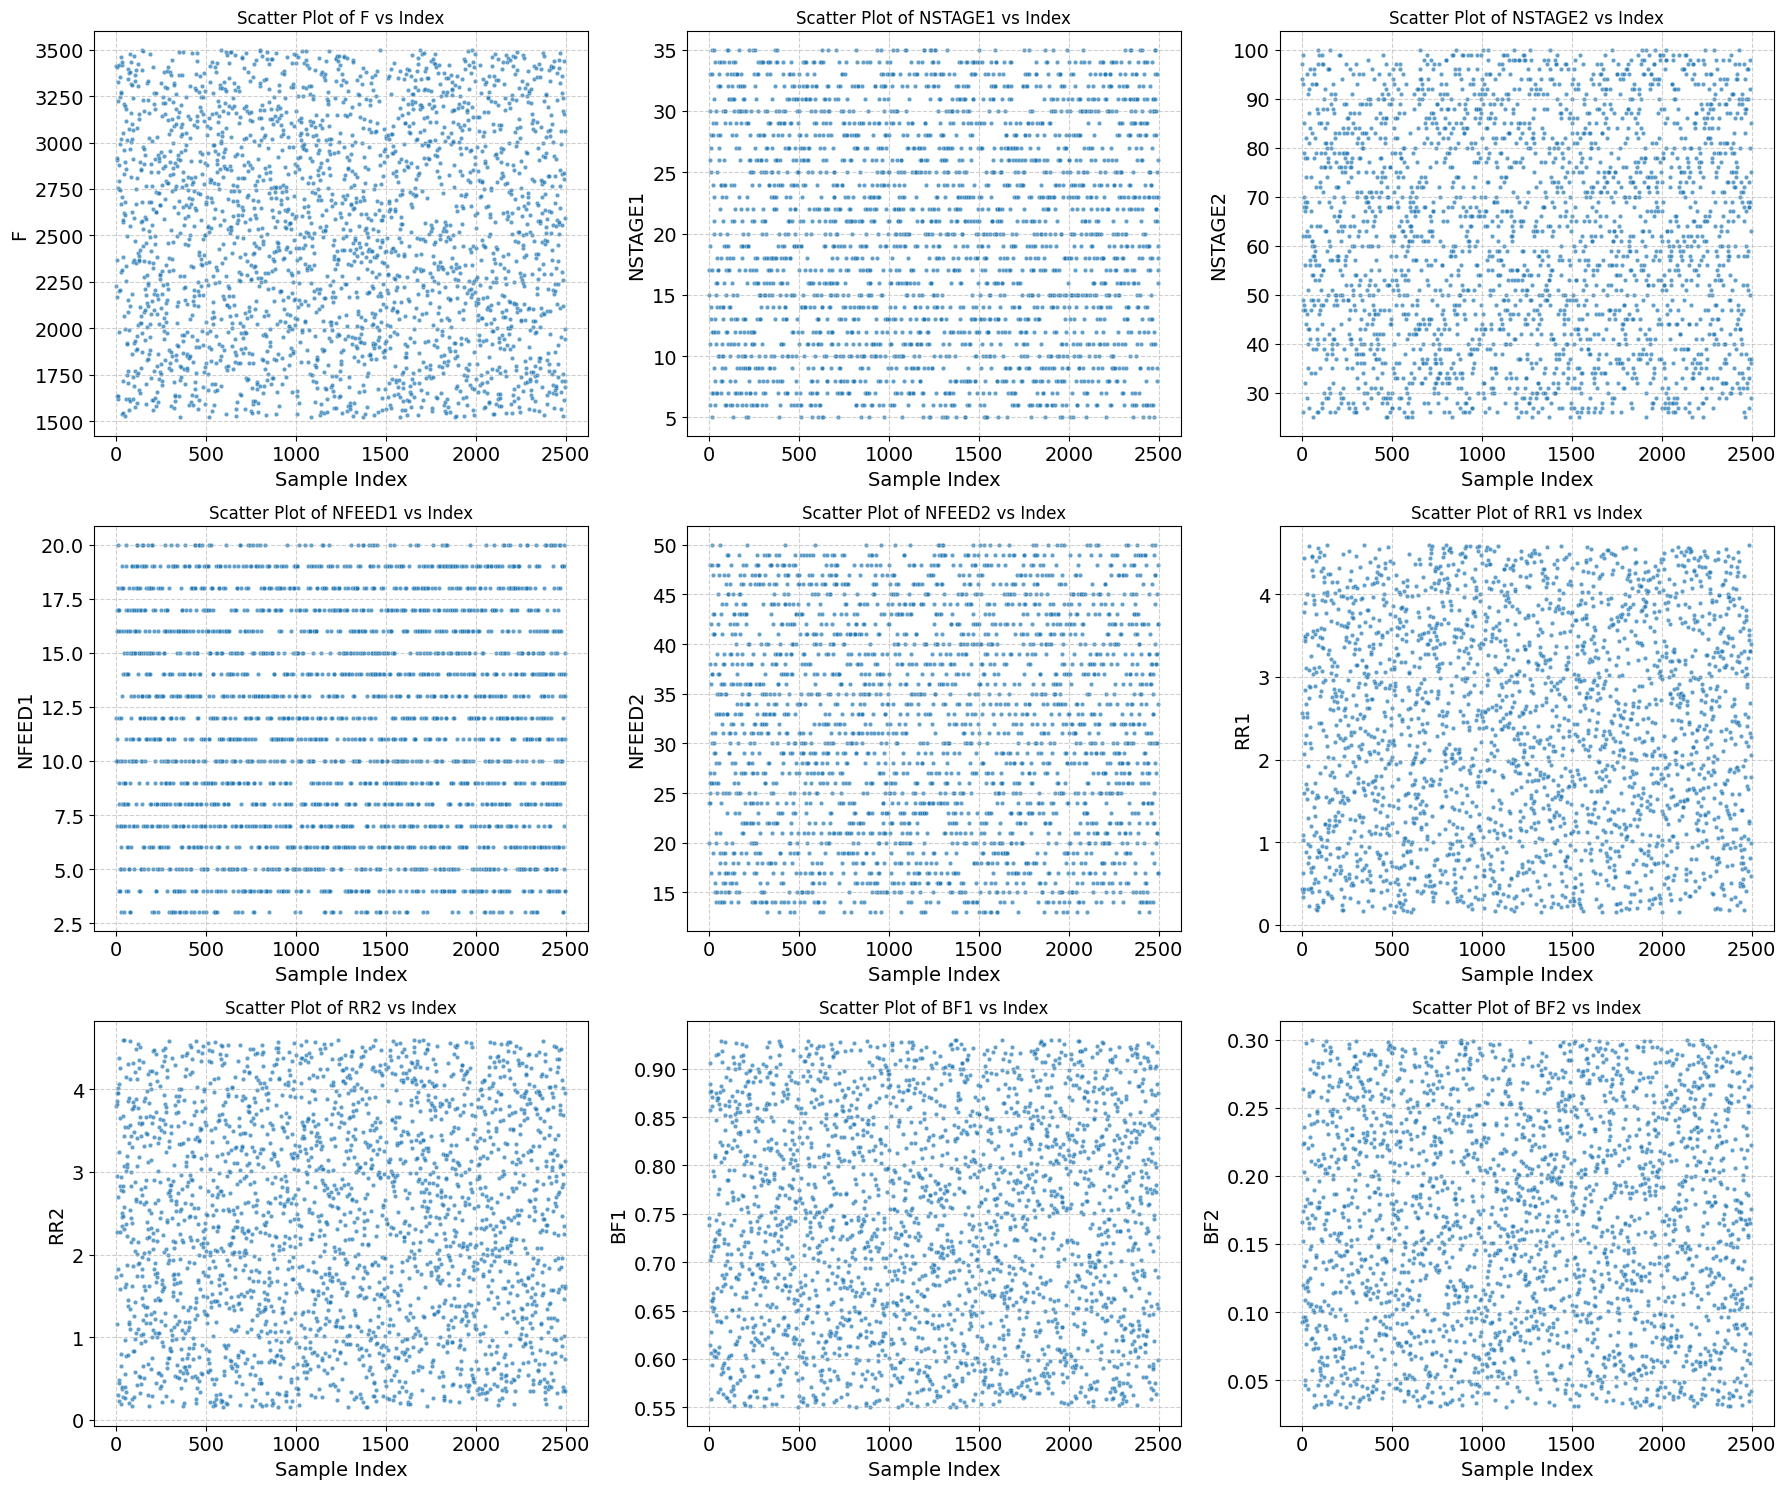

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the columns from the design_df
columns = design_df.columns

# Determine the number of rows and columns for the subplots dynamically
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols # Ceiling division

plt.figure(figsize=(n_cols * 6, n_rows * 5))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=design_df.index, y=design_df[col], s=10, alpha=0.7)
    plt.title(f'Scatter Plot of {col} vs Index')
    plt.xlabel('Sample Index', fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
inputs_df = pd.read_csv('/content/Inputs.csv')
outputs_df = pd.read_csv('/content/Outputs.csv')

Merged DataFrame head:


,FEED (F),N1,N2,NF1,NF2,RR1,RR2,BF1,BF2,Y,QR1,QR2,QC1,QC2,SAF,GREEN DIESEL (G),NAPHTHA (N)
0,2648.52940,23,49,15,32,2.079952,0.818881,0.834026,0.125839,2208.941709,261.086861,406.990815,104.347078,380.447743,1930.99472,277.977819,439.426188
1,2721.86502,25,81,12,48,3.724440,1.669400,0.852012,0.192014,2319.061308,310.544079,549.596328,164.043225,522.070430,1872.57964,444.882342,404.326821
2,2696.49778,33,92,15,39,2.891591,2.542245,0.609872,0.126840,1644.517944,565.764767,455.144304,379.405870,447.268990,1435.96785,208.381168,1052.209890
3,2187.07408,25,48,9,21,3.374510,2.674652,0.727839,0.030098,1591.837846,367.927469,570.503974,226.477867,565.947980,1543.90853,47.936884,595.356381
4,2370.66917,15,94,12,15,0.727699,3.098784,0.554849,0.089258,1315.362553,343.330017,420.139023,175.229070,417.114383,1198.08292,117.419505,1055.273720


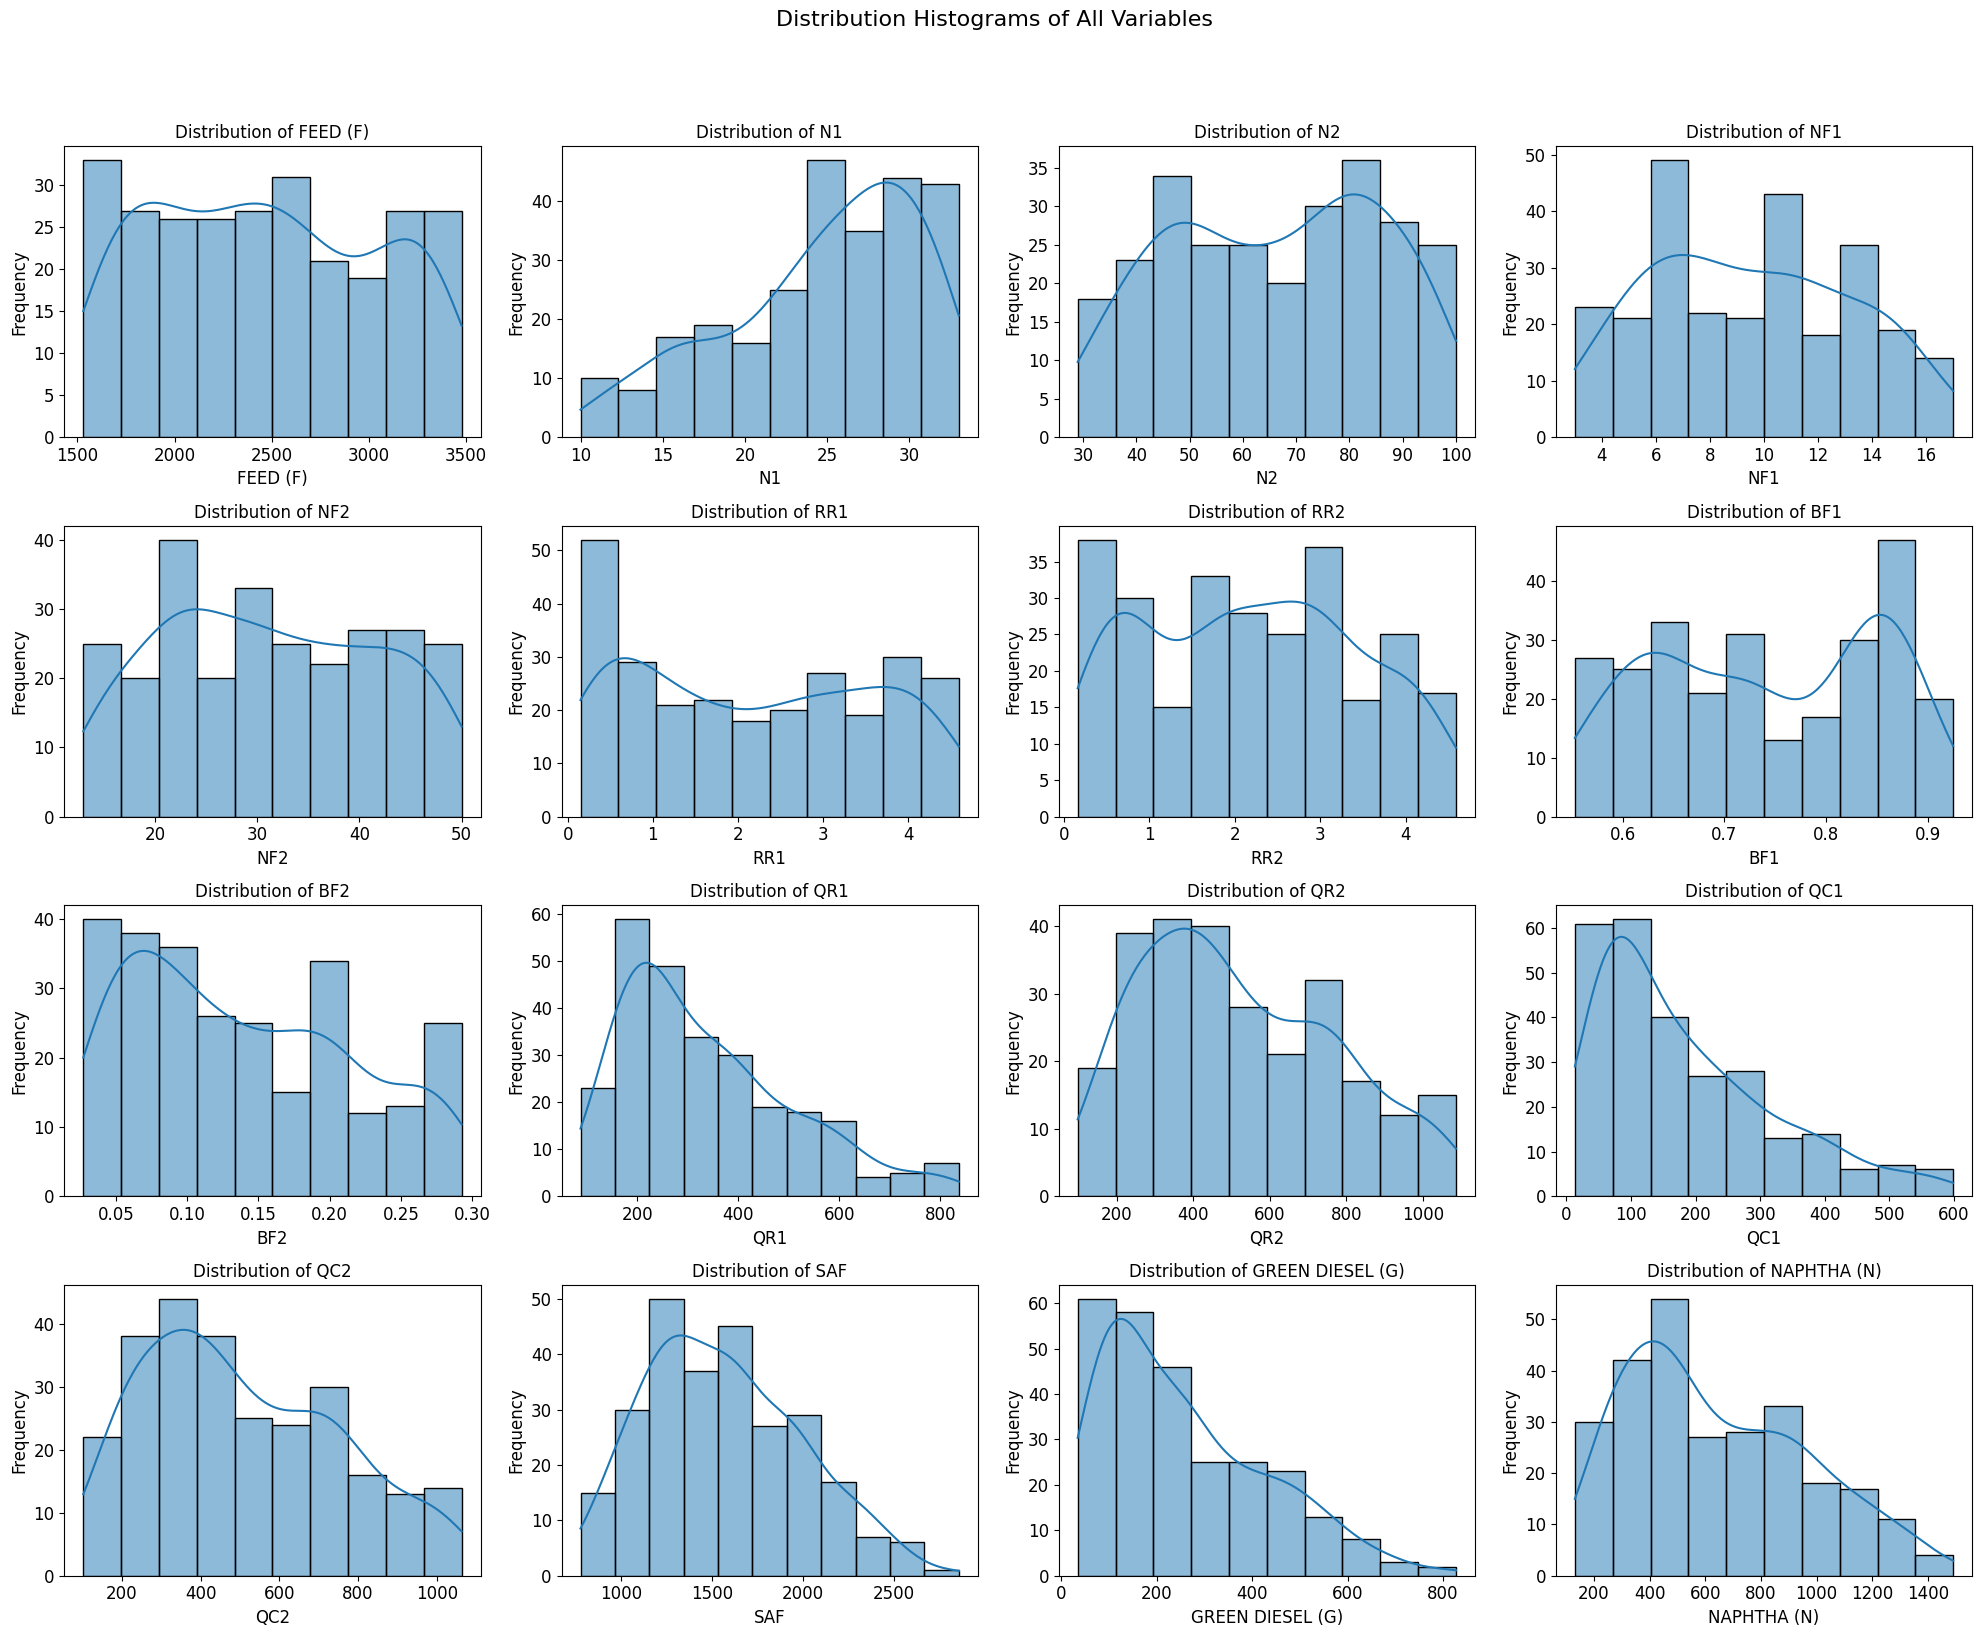

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the input and output data


# Assuming the rows correspond, merge by concatenating along columns
# If there were a common ID column, a proper merge (pd.merge) would be used.
# For now, we'll concatenate assuming they are aligned by index.
merged_df = pd.concat([inputs_df, outputs_df], axis=1)

print("Merged DataFrame head:")
display(merged_df.head())

# Plot distribution histograms for all variables, excluding 'Input Flow 2'
columns = [col for col in merged_df.columns if col != 'Y'] # Exclude 'Input flow 2'
n_cols = 4 # Number of columns for subplots
n_rows = (len(columns) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(merged_df[col], kde=True) # Plot histogram with KDE
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=12)

plt.suptitle('Distribution Histograms of All Variables', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

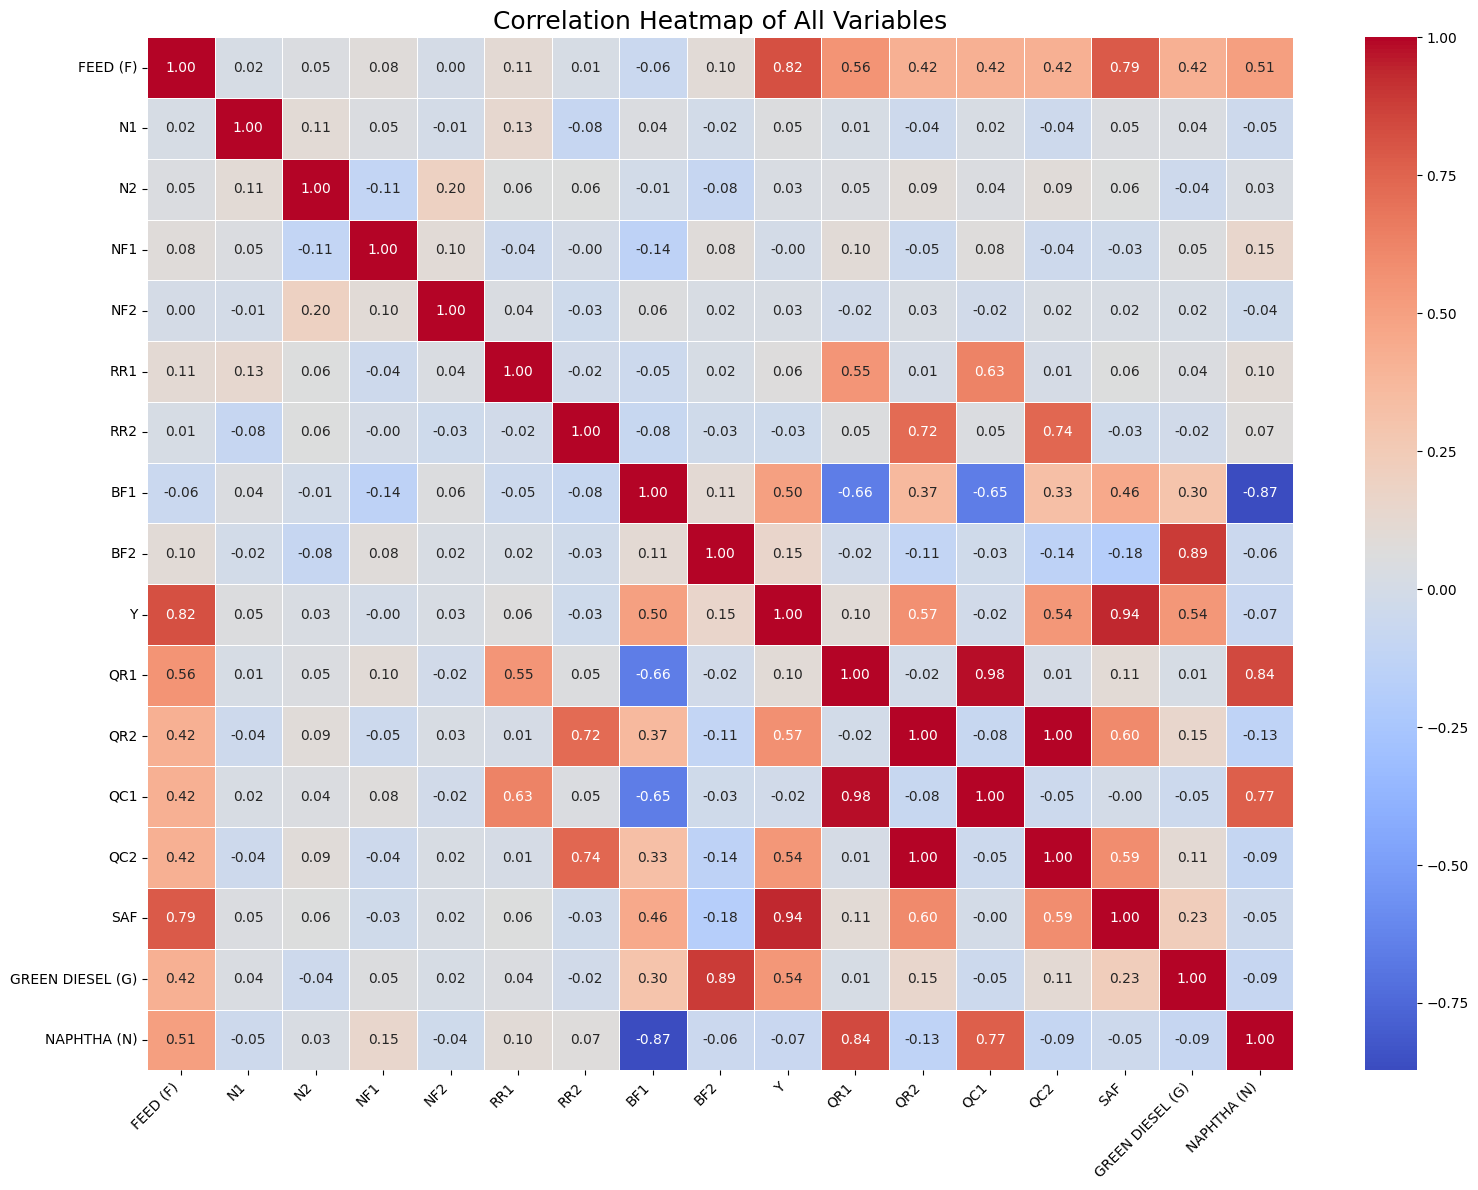

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = merged_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of All Variables', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print("Detailed Statistical Summary of merged_df:")
display(merged_df.describe())

Detailed Statistical Summary of merged_df:


,FEED (F),N1,N2,NF1,NF2,RR1,RR2,BF1,BF2,Y,QR1,QR2,QC1,QC2,SAF,GREEN DIESEL (G),NAPHTHA (N)
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,2464.094468,24.696970,66.064394,9.522727,31.268939,2.183031,2.188653,0.740879,0.138573,1821.550699,338.797547,520.915639,183.650452,507.259641,1563.243730,258.188737,642.669587
std,570.807188,5.876989,19.749756,3.769935,10.563929,1.412724,1.256770,0.110266,0.077171,492.898302,169.308123,251.772630,136.168000,247.872997,424.756838,171.973950,324.428170
min,1530.619000,10.000000,29.000000,3.000000,13.000000,0.150541,0.163453,0.553072,0.027228,961.046284,87.956935,97.614014,13.138400,101.813460,774.706098,34.599827,131.220965
25%,1954.114595,21.000000,49.000000,6.000000,22.000000,0.833132,0.981864,0.637793,0.069313,1429.742134,204.538798,325.008275,74.911492,308.327640,1238.001700,120.926304,379.492733
50%,2433.457895,26.000000,67.000000,9.000000,30.000000,2.142064,2.166770,0.732390,0.125792,1741.329943,294.590487,471.667122,140.755242,457.563066,1535.028330,215.012412,556.743612
75%,2958.786448,29.000000,82.250000,13.000000,40.000000,3.428220,3.117479,0.850486,0.196724,2152.030172,440.252639,716.171375,266.037157,701.922174,1872.825722,377.314602,891.477921
max,3476.780670,33.000000,100.000000,17.000000,50.000000,4.593075,4.586652,0.924572,0.292601,2939.677609,836.329908,1086.764200,598.637216,1063.287360,2857.418220,827.215971,1490.397000


Generating multipanel scatter plots for pairs with correlation > 0.7:


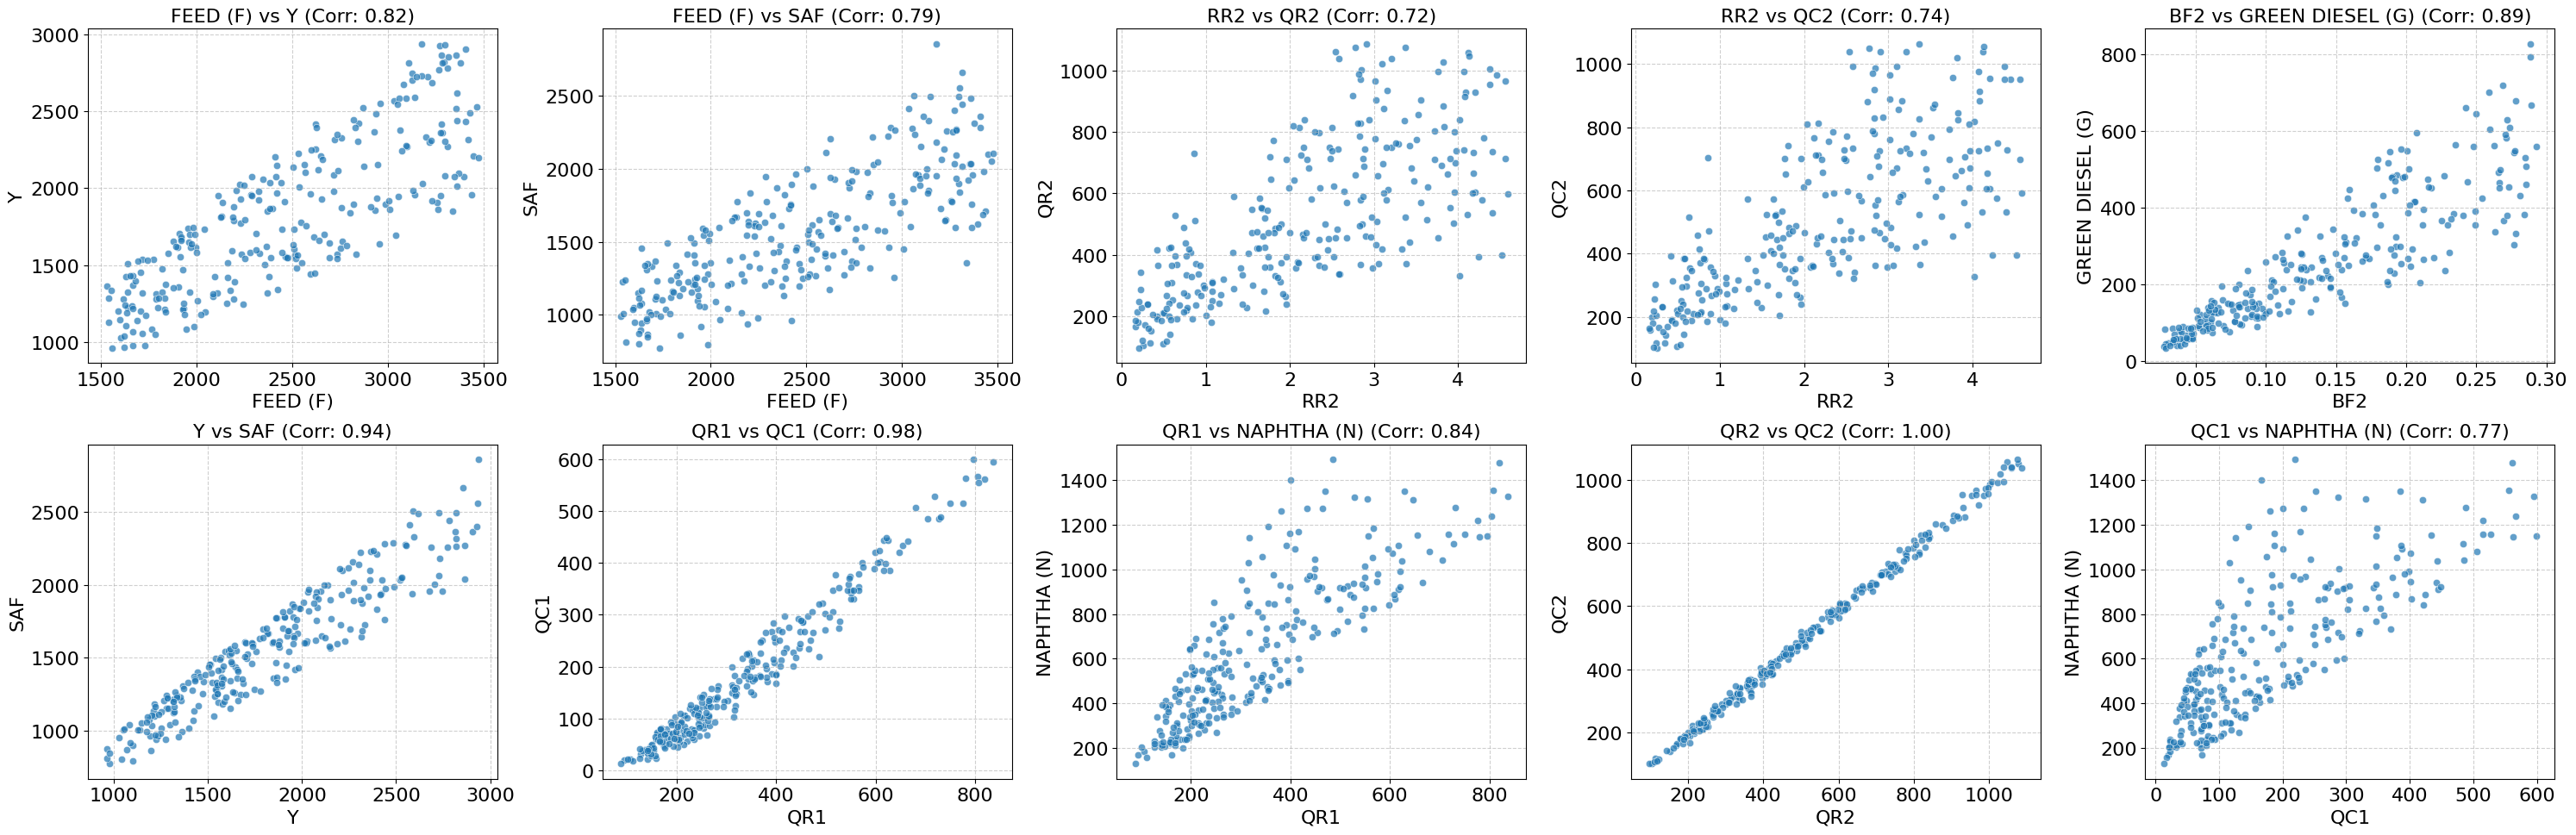

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming merged_df and correlation_matrix are available from previous steps

# Identify pairs with correlation > 0.7
high_corr_pairs = []
columns = correlation_matrix.columns

# Iterate through the upper triangle of the correlation matrix to avoid duplicates
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1 = columns[i]
        col2 = columns[j]
        corr_val = correlation_matrix.loc[col1, col2]

        if corr_val > 0.7: # Changed from > 0.5 to > 0.7
            high_corr_pairs.append((col1, col2, corr_val))

# Generate scatter plots for identified pairs in a multipanel layout
if high_corr_pairs:
    print("Generating multipanel scatter plots for pairs with correlation > 0.7:")

    n_plots = len(high_corr_pairs)
    n_cols = 5 # Number of columns for the multipanel plot
    n_rows = (n_plots + n_cols - 1) // n_cols # Calculate rows needed (ceiling division)

    plt.figure(figsize=(n_cols * 6, n_rows * 5))

    for i, (col1, col2, corr_val) in enumerate(high_corr_pairs):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.scatterplot(data=merged_df, x=col1, y=col2, alpha=0.7)
        plt.title(f'{col1} vs {col2} (Corr: {corr_val:.2f})', fontsize=16)
        plt.xlabel(col1, fontsize=16)
        plt.ylabel(col2, fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tick_params(axis='both', which='major', labelsize=16)
    #plt.suptitle('Multipanel Scatter Plots for Variables with Correlation > 0.7', y=1.02, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("No pairs found with a correlation coefficient greater than 0.7.")

Training ANN-based Surrogate Model

In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import joblib

# --- Configuration---
best_mse = float('inf')
best_mb_error = float('inf')
results = []
num_runs = 50

# --- Custom loss ---
def custom_physics_loss(y_true, y_pred, x_batch, x_scaler, y_scaler, penalty_weight):
    # 1. MSE
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

    # 2. Balance in real scale
    x_mean = tf.cast(x_scaler.mean_[0], tf.float32)
    x_std = tf.cast(x_scaler.scale_[0], tf.float32)
    y_means = tf.cast(y_scaler.mean_[4:7], tf.float32)
    y_stds = tf.cast(y_scaler.scale_[4:7], tf.float32)

    feed_orig = x_batch[:, 0] * x_std + x_mean
    y_out_4 = y_pred[:, 4] * y_stds[0] + y_means[0]
    y_out_5 = y_pred[:, 5] * y_stds[1] + y_means[1]
    y_out_6 = y_pred[:, 6] * y_stds[2] + y_means[2]

    balance_error_real = feed_orig - (y_out_4 + y_out_5 + y_out_6)

    # 3. NORMALIZATION of PENALTY
    balance_penalty_normalized = tf.reduce_mean(tf.square(balance_error_real / x_std))

    return mse_loss + (penalty_weight * balance_penalty_normalized)

# Index array to ensure same split
indices = np.arange(len(X))

for run_number in range(num_runs):
    print(f"--- Run {run_number + 1}/{num_runs} ---")

    # Split and indices
    X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
        X, y, indices, test_size=0.15, random_state=run_number+1
    )

    X_scaler, y_scaler = StandardScaler(), StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train).astype(np.float32)
    y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
    X_test_scaled = X_scaler.transform(X_test).astype(np.float32)

    lr=0.01
    for penalty in [1.0]:
        for layer_size in [12]:
            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='tanh'),
                Dense(y_train_scaled.shape[1], activation='linear')
            ])
            optimizer = Adam(learning_rate=lr)
            train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train_scaled)).batch(64)

            # Best epoch tracking
            min_loss_in_run = float('inf')
            best_weights = None
            best_epoch_num = 0

            # Training loop
            for epoch in range(500):
                epoch_losses = []
                for x_batch, y_batch in train_dataset:
                    with tf.GradientTape() as tape:
                        preds = model(x_batch, training=True)
                        loss_value = custom_physics_loss(y_batch, preds, x_batch, X_scaler, y_scaler, penalty)
                    grads = tape.gradient(loss_value, model.trainable_variables)
                    optimizer.apply_gradients(zip(grads, model.trainable_variables))
                    epoch_losses.append(loss_value.numpy())

                avg_epoch_loss = np.mean(epoch_losses)
                if avg_epoch_loss < min_loss_in_run:
                    min_loss_in_run = avg_epoch_loss
                    best_weights = model.get_weights()
                    best_epoch_num = epoch + 1

            # Load best parameters
            model.set_weights(best_weights)

            # Evaluate
            y_train_pred = y_scaler.inverse_transform(model.predict(X_train_scaled, verbose=0))
            y_test_pred = y_scaler.inverse_transform(model.predict(X_test_scaled, verbose=0))

            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train = r2_score(y_train, y_train_pred)
            mse_test = mean_squared_error(y_test, y_test_pred)
            r2_test = r2_score(y_test, y_test_pred)

            # Test mass balance error
            mb_error = np.mean(np.abs(X_test[:,0] - np.sum(y_test_pred[:,4:7], axis=1)))

            results.append({
                'run': run_number + 1,
                'layer_size': layer_size,
                'lr': lr,
                'penalty': penalty,
                'loss': min_loss_in_run,
                'best_epoch': best_epoch_num,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_test': mse_test,
                'r2_test': r2_test,
                'balance_error': mb_error,
                'train_indices': train_idx.tolist(),
                'test_indices': test_idx.tolist()
            })

            if mse_test < best_mse:
                best_mse = mse_test
                best_params = {'run': run_number + 1, 'layer_size': layer_size, 'lr': lr, 'epoch': best_epoch_num}
                best_model = model
                joblib.dump(X_scaler, 'overall_best_X_scaler.joblib')
                joblib.dump(y_scaler, 'overall_best_y_scaler.joblib')
                best_model.save('overall_best_model_run_based.keras')
                # Save best model indices
                np.save('overall_best_train_indices.npy', train_idx)
                np.save('overall_best_test_indices.npy', test_idx)

            if  mb_error < best_mb_error:
                best_mb_error = mb_error
                best_params_mb = {'run': run_number + 1, 'layer_size': layer_size, 'lr': lr, 'epoch': best_epoch_num}
                best_model_mb = model
                joblib.dump(X_scaler, 'mb_best_X_scaler.joblib')
                joblib.dump(y_scaler, 'mb_best_y_scaler.joblib')
                best_model_mb.save('mb_best_model_run_based.keras')
                # Save best model indices
                np.save('mb_best_train_indices.npy', train_idx)
                np.save('mb_best_test_indices.npy', test_idx)

# Save results as csv
results_df = pd.DataFrame(results)
results_df.to_csv('all_runs_results_and_indices_mb_final.csv', index=False)

print(f"\nOverall Best Configuration: {best_params} with MSE_val: {best_mse:.4f}")
print(f"\nBest Configuration with lowest mass balance error: {best_params_mb} with mean balance error: {best_mb_error:.4f}")
display(results_df.drop(columns=['train_indices', 'test_indices']))

--- Run 1/50 ---
--- Run 2/50 ---
--- Run 3/50 ---
--- Run 4/50 ---
--- Run 5/50 ---
--- Run 6/50 ---
--- Run 7/50 ---
--- Run 8/50 ---
--- Run 9/50 ---
--- Run 10/50 ---
--- Run 11/50 ---
--- Run 12/50 ---
--- Run 13/50 ---
--- Run 14/50 ---
--- Run 15/50 ---
--- Run 16/50 ---
--- Run 17/50 ---
--- Run 18/50 ---
--- Run 19/50 ---
--- Run 20/50 ---
--- Run 21/50 ---
--- Run 22/50 ---
--- Run 23/50 ---
--- Run 24/50 ---
--- Run 25/50 ---
--- Run 26/50 ---
--- Run 27/50 ---
--- Run 28/50 ---
--- Run 29/50 ---
--- Run 30/50 ---
--- Run 31/50 ---
--- Run 32/50 ---
--- Run 33/50 ---
--- Run 34/50 ---
--- Run 35/50 ---
--- Run 36/50 ---
--- Run 37/50 ---
--- Run 38/50 ---
--- Run 39/50 ---
--- Run 40/50 ---
--- Run 41/50 ---
--- Run 42/50 ---
--- Run 43/50 ---
--- Run 44/50 ---
--- Run 45/50 ---
--- Run 46/50 ---
--- Run 47/50 ---
--- Run 48/50 ---
--- Run 49/50 ---
--- Run 50/50 ---

Overall Best Configuration: {'run': 3, 'layer_size': 12, 'lr': 0.01, 'epoch': 500} with MSE_val: 221.7994

B

,run,layer_size,lr,penalty,loss,best_epoch,mse_train,r2_train,mse_test,r2_test,balance_error
0,1,12,0.01,1.0,0.004697,500,257.576314,0.995443,271.314656,0.994128,7.790711
1,2,12,0.01,1.0,0.003982,499,221.310965,0.996162,546.905168,0.988207,7.190599
2,3,12,0.01,1.0,0.004675,500,256.172249,0.995661,221.799422,0.995059,9.294397
3,4,12,0.01,1.0,0.004054,478,225.896636,0.996192,315.213526,0.993166,8.328494
4,5,12,0.01,1.0,0.003943,500,215.008512,0.996195,295.023670,0.994674,4.257167
5,6,12,0.01,1.0,0.004466,460,224.994524,0.996219,420.587409,0.992476,10.328294
6,7,12,0.01,1.0,0.006116,500,267.094769,0.993947,425.431595,0.990882,10.977169
7,8,12,0.01,1.0,0.004300,500,257.603176,0.995836,508.689184,0.991089,5.695655
8,9,12,0.01,1.0,0.005307,500,273.071899,0.994900,276.153099,0.991586,8.742775
9,10,12,0.01,1.0,0.004050,483,226.187776,0.996170,283.852011,0.994697,8.056338


In [ ]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Define the file paths for the overall best model and its components
overall_best_model_filepath_run_based = 'mb_best_model_run_based.keras'
overall_best_train_indices_filepath = 'mb_best_train_indices.npy'
overall_best_test_indices_filepath = 'mb_best_test_indices.npy'

overall_best_X_scaler_filepath = 'mb_best_X_scaler.joblib'
overall_best_y_scaler_filepath = 'mb_best_y_scaler.joblib'

# Load the best model
best_model_loaded = load_model(overall_best_model_filepath_run_based)

# Load the corresponding scalers
best_X_scaler_loaded = joblib.load(overall_best_X_scaler_filepath)
best_y_scaler_loaded = joblib.load(overall_best_y_scaler_filepath)

# Load the train and test indices
best_train_indices = np.load(overall_best_train_indices_filepath)
best_test_indices = np.load(overall_best_test_indices_filepath)

print("Best model loaded successfully.")
print("Best X scaler loaded successfully.")
print("Best y scaler loaded successfully.")
print(f"Train indices loaded (first 5): {best_train_indices[:5]}")
print(f"Test indices loaded (first 5): {best_test_indices[:5]}")


Best model loaded successfully.
Best X scaler loaded successfully.
Best y scaler loaded successfully.
Train indices loaded (first 5): [201 139 202 232 107]
Test indices loaded (first 5): [165 191 197 127 154]


In [ ]:
import pandas as pd

# Combine X and y into a single DataFrame
combined_df = pd.concat([inputs_df, outputs_df], axis=1)

# Initialize a 'SET' column with a default value (e.g., 'UNKNOWN')
combined_df['SET'] = 'UNKNOWN'

# Assign 'TRAIN' to rows based on reconstructed_train_indices
combined_df.loc[best_train_indices, 'SET'] = 'TRAIN'

# Assign 'TEST' to rows based on reconstructed_test_indices
combined_df.loc[best_test_indices, 'SET'] = 'TEST'

print("Combined DataFrame created successfully with 'SET' column.")
display(combined_df.head())

# Display value counts for the 'SET' column to verify
print("\nDistribution of data points in 'SET' column:")
display(combined_df['SET'].value_counts())

Combined DataFrame created successfully with 'SET' column.


,FEED (F),N1,N2,NF1,NF2,RR1,RR2,BF1,BF2,Y,QR1,QR2,QC1,QC2,SAF,GREEN DIESEL (G),NAPHTHA (N),SET
0,2648.52940,23,49,15,32,2.079952,0.818881,0.834026,0.125839,2208.941709,261.086861,406.990815,104.347078,380.447743,1930.99472,277.977819,439.426188,TRAIN
1,2721.86502,25,81,12,48,3.724440,1.669400,0.852012,0.192014,2319.061308,310.544079,549.596328,164.043225,522.070430,1872.57964,444.882342,404.326821,TRAIN
2,2696.49778,33,92,15,39,2.891591,2.542245,0.609872,0.126840,1644.517944,565.764767,455.144304,379.405870,447.268990,1435.96785,208.381168,1052.209890,TRAIN
3,2187.07408,25,48,9,21,3.374510,2.674652,0.727839,0.030098,1591.837846,367.927469,570.503974,226.477867,565.947980,1543.90853,47.936884,595.356381,TEST
4,2370.66917,15,94,12,15,0.727699,3.098784,0.554849,0.089258,1315.362553,343.330017,420.139023,175.229070,417.114383,1198.08292,117.419505,1055.273720,TRAIN



Distribution of data points in 'SET' column:


SET
TRAIN    224
TEST      40
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# 1. Load the best model and scalers
model = load_model('mb_best_model_run_based.keras')
scaler_X = joblib.load('mb_best_X_scaler.joblib')
scaler_y = joblib.load('mb_best_y_scaler.joblib')

# 2. Prepare the full input data
# Fix: inputs_df already contains 10 features (including the F*BF1 interaction)
X_full = inputs_df.values

# 3. Scale and Predict
X_scaled = scaler_X.transform(X_full)
y_pred_scaled = model.predict(X_scaled, verbose=0)

# 4. Inverse transform to original units
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)

# 5. Create a DataFrame with the predictions
pred_cols = ['pred_QR1', 'pred_QR2', 'pred_QC1', 'pred_QC2', 'pred_SAF', 'pred_Greendiesel', 'pred_Naphtha']
predictions_df = pd.DataFrame(y_pred_real, columns=pred_cols)

# 6. Merge with combined_df
# Ensure we don't duplicate columns if the cell is re-run
combined_df = combined_df.loc[:, ~combined_df.columns.isin(pred_cols)]
combined_df = pd.concat([combined_df.reset_index(drop=True), predictions_df.reset_index(drop=True)], axis=1)

print("Predictions generated and merged into combined_df.")
display(combined_df.head())

# Save to CSV for convenience
combined_df.to_csv('combined_data_with_predictions.csv', index=False)
print("Saved to 'combined_data_with_predictions.csv'")

Predictions generated and merged into combined_df.


,FEED (F),N1,N2,NF1,NF2,RR1,RR2,BF1,BF2,Y,...,GREEN DIESEL (G),NAPHTHA (N),SET,pred_QR1,pred_QR2,pred_QC1,pred_QC2,pred_SAF,pred_Greendiesel,pred_Naphtha
0,2648.52940,23,49,15,32,2.079952,0.818881,0.834026,0.125839,2208.941709,...,277.977819,439.426188,TRAIN,257.248688,398.247498,110.736732,373.457092,1941.613403,277.044067,425.649353
1,2721.86502,25,81,12,48,3.724440,1.669400,0.852012,0.192014,2319.061308,...,444.882342,404.326821,TRAIN,296.916962,564.464294,146.548035,535.524475,1871.033203,443.915222,404.485992
2,2696.49778,33,92,15,39,2.891591,2.542245,0.609872,0.126840,1644.517944,...,208.381168,1052.209890,TRAIN,570.024292,471.331573,373.356689,472.580933,1443.242554,209.102203,1047.466919
3,2187.07408,25,48,9,21,3.374510,2.674652,0.727839,0.030098,1591.837846,...,47.936884,595.356381,TEST,359.984558,582.099731,215.967392,581.595459,1546.307617,47.527847,596.033508
4,2370.66917,15,94,12,15,0.727699,3.098784,0.554849,0.089258,1315.362553,...,117.419505,1055.273720,TRAIN,340.247375,399.496185,168.443542,401.280579,1191.045288,120.604370,1059.990479


Saved to 'combined_data_with_predictions.csv'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# Reconstruct X_train, y_train, X_test, y_test using the indices
X_train_best_run = X[best_train_indices]
y_train_best_run = y[best_train_indices]
X_test_best_run = X[best_test_indices]
y_test_best_run = y[best_test_indices]

# Scale the data using the loaded best scalers
X_train_scaled_best_run = best_X_scaler_loaded.transform(X_train_best_run)
X_test_scaled_best_run = best_X_scaler_loaded.transform(X_test_best_run)

# Make predictions on the scaled data
y_train_pred_scaled_best_run = best_model_loaded.predict(X_train_scaled_best_run, verbose=0)
y_test_pred_scaled_best_run = best_model_loaded.predict(X_test_scaled_best_run, verbose=0)

# Inverse transform the predictions to original scale
y_train_pred_best_run = best_y_scaler_loaded.inverse_transform(y_train_pred_scaled_best_run)
y_test_pred_best_run = best_y_scaler_loaded.inverse_transform(y_test_pred_scaled_best_run)

# Calculate metrics for each output separately for train set
mse_train_per_output = mean_squared_error(y_train_best_run, y_train_pred_best_run, multioutput='raw_values')
r2_train_per_output = r2_score(y_train_best_run, y_train_pred_best_run, multioutput='raw_values')

# Calculate metrics for each output separately for test set
mse_test_per_output = mean_squared_error(y_test_best_run, y_test_pred_best_run, multioutput='raw_values')
r2_test_per_output = r2_score(y_test_best_run, y_test_pred_best_run, multioutput='raw_values')

# Calculate metrics for all test set
mse_test_all = mean_squared_error(y_test_best_run, y_test_pred_best_run)
r2_test_all= r2_score(y_test_best_run, y_test_pred_best_run)

print("\n--- Evaluation of Overall Best Model Per Output ---")
for i in range(y.shape[1]):
    print(f"Output {i+1}:")
    print(f"  Train MSE: {mse_train_per_output[i]:.4f}")
    print(f"  Train R2: {r2_train_per_output[i]:.4f}")
    print(f"  Test MSE: {mse_test_per_output[i]:.4f}")
    print(f"  Test R2: {r2_test_per_output[i]:.4f}")
    print("---------------------------------------------------")

print("\n--- Overall Best Model Overall Performance ---")
print(f"Test MSE: {mse_test_all:.4f}")
print(f"Test R2: {r2_test_all:.4f}")
print("---------------------------------------------------")


--- Evaluation of Overall Best Model Per Output ---
Output 1:
  Train MSE: 58.4711
  Train R2: 0.9977
  Test MSE: 189.6023
  Test R2: 0.9954
---------------------------------------------------
Output 2:
  Train MSE: 478.1483
  Train R2: 0.9926
  Test MSE: 602.4104
  Test R2: 0.9894
---------------------------------------------------
Output 3:
  Train MSE: 70.2281
  Train R2: 0.9958
  Test MSE: 140.9263
  Test R2: 0.9946
---------------------------------------------------
Output 4:
  Train MSE: 592.8600
  Train R2: 0.9905
  Test MSE: 711.5517
  Test R2: 0.9870
---------------------------------------------------
Output 5:
  Train MSE: 136.8135
  Train R2: 0.9992
  Test MSE: 191.8564
  Test R2: 0.9988
---------------------------------------------------
Output 6:
  Train MSE: 29.1447
  Train R2: 0.9990
  Test MSE: 30.7707
  Test R2: 0.9992
---------------------------------------------------
Output 7:
  Train MSE: 139.3938
  Train R2: 0.9986
  Test MSE: 198.0479
  Test R2: 0.9984
---------

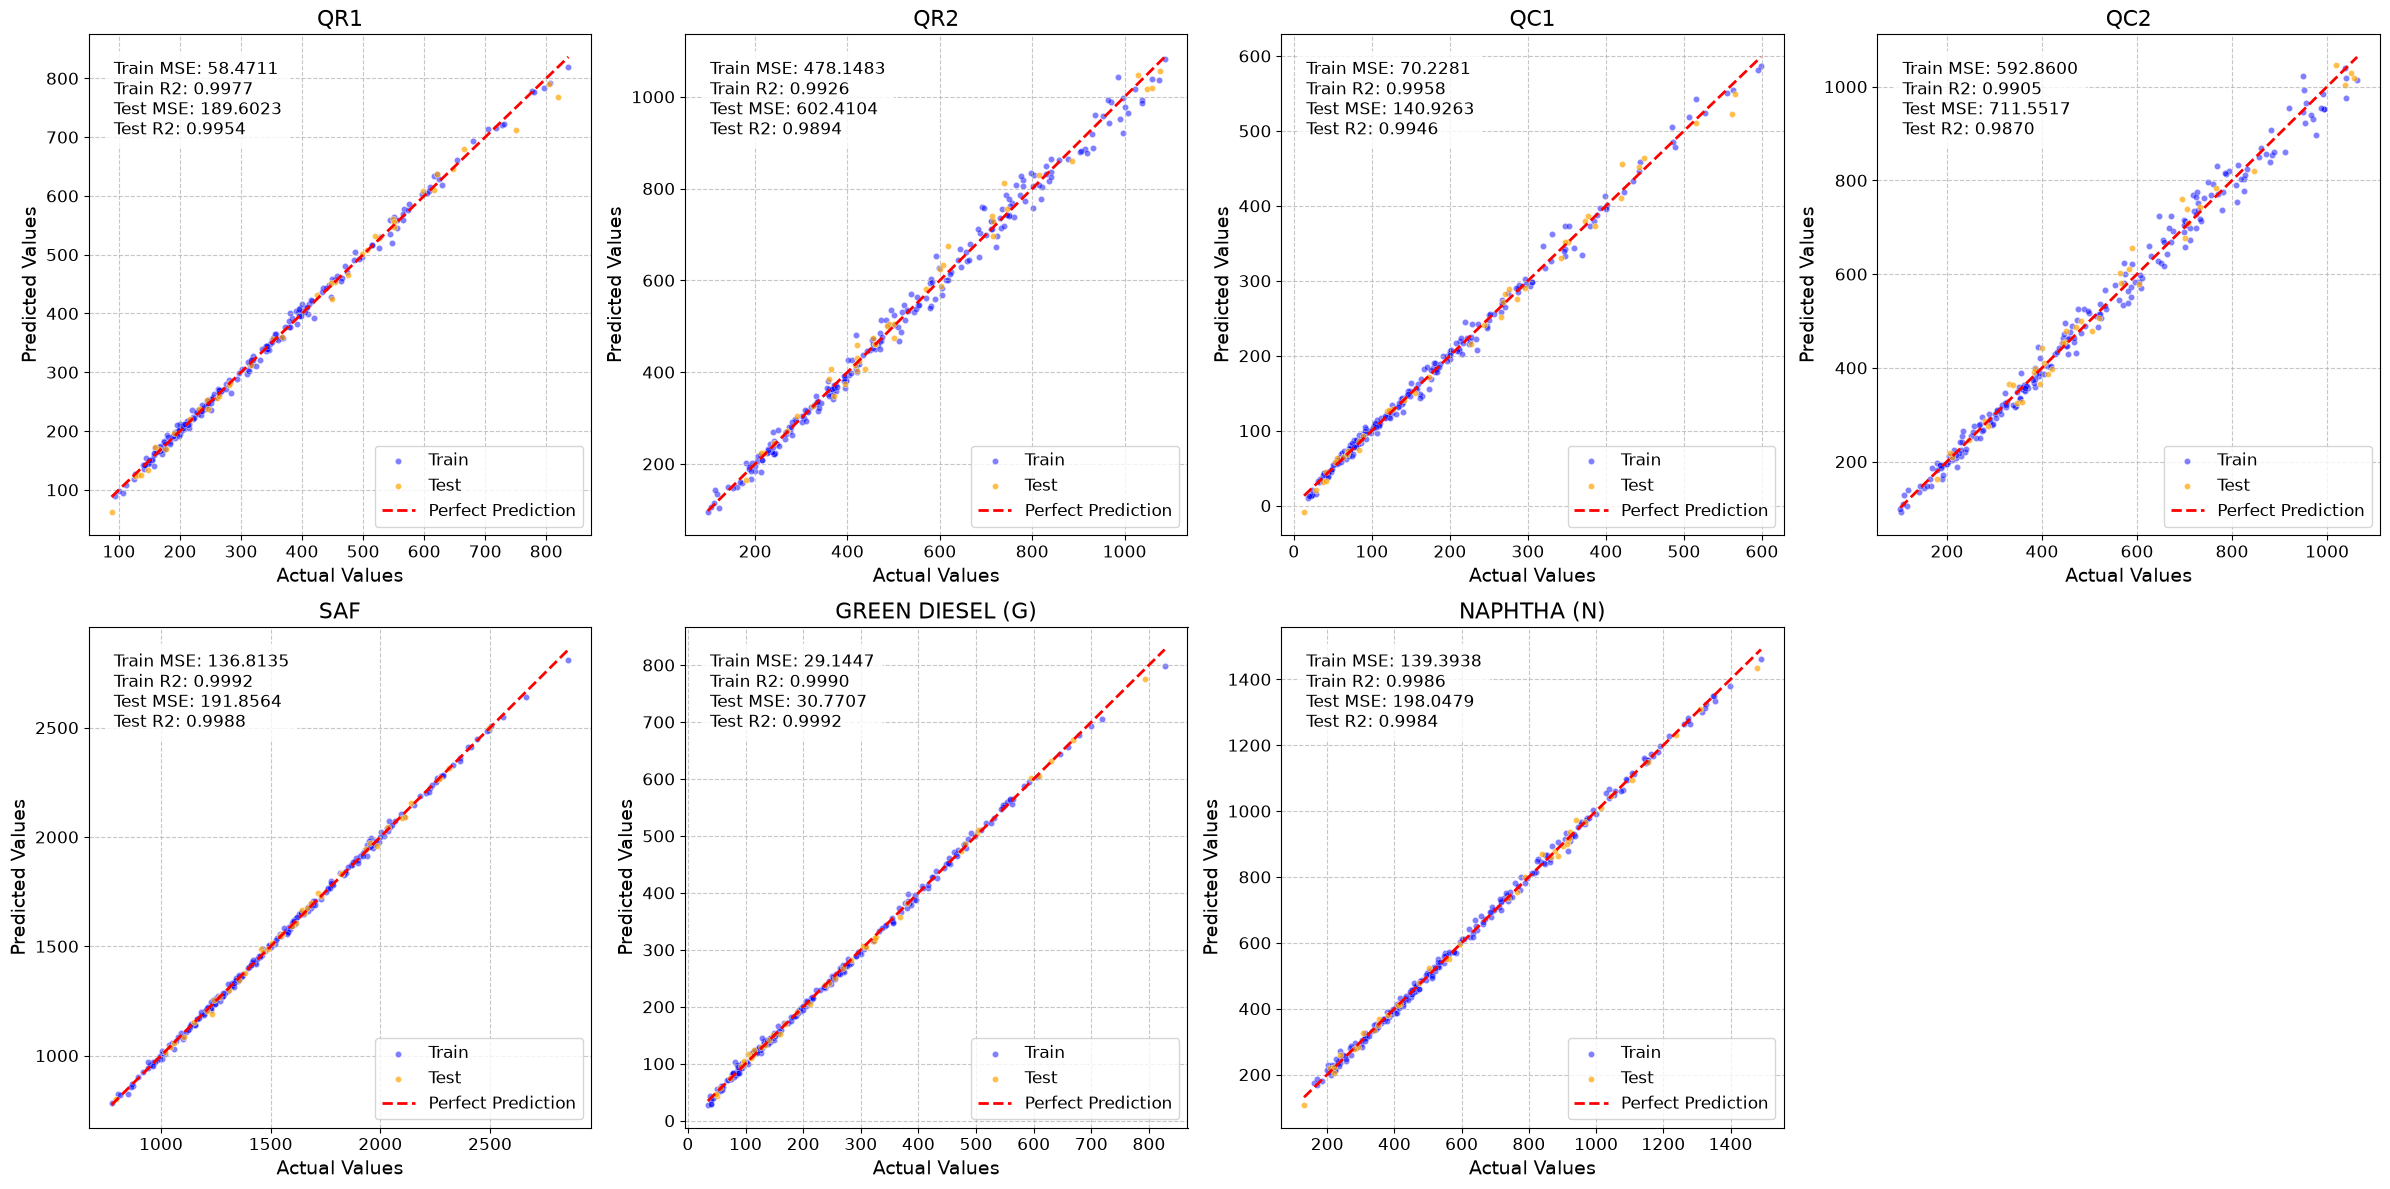

In [ ]:
import math

num_outputs = y_train_best_run.shape[1] # Get the number of output variables

# Determine grid size for subplots
cols = min(4, num_outputs) # Max 4 columns for better readability
rows = math.ceil(num_outputs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6), squeeze=False) # squeeze=False ensures axes is always 2D
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

columns_names=['QR1',	'QR2',	'QC1',	'QC2',	'SAF',	'GREEN DIESEL (G)',	'NAPHTHA (N)']

for i in range(num_outputs):
    ax = axes[i]

    # Get min/max for the parity line, considering both train and test data
    min_val = min(y_train_best_run[:, i].min(), y_test_best_run[:, i].min())
    max_val = max(y_train_best_run[:, i].max(), y_test_best_run[:, i].max())

    # Plot Training Set
    sns.scatterplot(x=y_train_best_run[:, i], y=y_train_pred_best_run[:, i], ax=ax, alpha=0.5, label='Train', color='blue', s=20)
    # Plot Test Set
    sns.scatterplot(x=y_test_best_run[:, i], y=y_test_pred_best_run[:, i], ax=ax, alpha=0.7, label='Test', color='orange', s=20)

    # Red dashed line for perfect prediction
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax.set_title(columns_names[i], fontsize=16)
    ax.set_xlabel('Actual Values', fontsize=14)
    ax.set_ylabel('Predicted Values', fontsize=14)

    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=12)
    # Set tick label fontsize
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    # Add MSE and R2 values as text annotations
    metrics_text = f"Train MSE: {mse_train_per_output[i]:.4f}\n" \
                   f"Train R2: {r2_train_per_output[i]:.4f}\n" \
                   f"Test MSE: {mse_test_per_output[i]:.4f}\n" \
                   f"Test R2: {r2_test_per_output[i]:.4f}"
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8, edgecolor='none'))

# Remove any unused subplots if num_outputs is not a perfect multiple of cols
for j in range(num_outputs, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import numpy as np
import optuna
from tensorflow.keras.models import load_model

# Ensure the TPESampler is used for Bayesian Optimization
from optuna.samplers import TPESampler

# =====================================================================
# 1. LOAD SAVED MODEL AND SCALERS GLOBALLY
# =====================================================================
surrogate_net = load_model("mb_best_model_run_based.keras")
scaler_X = joblib.load("mb_best_X_scaler.joblib")
scaler_y = joblib.load("mb_best_y_scaler.joblib")


def objective(trial):
    # Define parameter space matching your strict engineering limits
    F = trial.suggest_float("F", 2000, 2000)  # Kept constant

    # Using suggest_int for discrete equipment configurations
    NSTAGE1 = trial.suggest_int("NSTAGE1", 10, 33)
    NSTAGE2 = trial.suggest_int("NSTAGE2", 29, 100)
    NFEED1 = trial.suggest_int("NFEED1", 3, 17) #17
    NFEED2 = trial.suggest_int("NFEED2", 13, 50) #13,50

    # Continuous operational control metrics
    RR1 = trial.suggest_float("RR1", 0.15, 4.6) #4.5931
    RR2 = trial.suggest_float("RR2", 0.16, 4.6) #4.5867
    #BF1 = trial.suggest_float("BF1", 0.5531, 0.9246)
    BF1 = trial.suggest_float("BF1", 0.55, 0.92)
    #BF2 = trial.suggest_float("BF2", 0.0272, 0.2926)
    BF2 = trial.suggest_float("BF2", 0.07, 0.3)

    # Reconstruct the vector format for calculations, casting integers to floats
    x_vars = [
        float(F),
        float(NSTAGE1),
        float(NSTAGE2),
        float(NFEED1),
        float(NFEED2),
        float(RR1),
        float(RR2),
        float(BF1),
        float(BF2),
    ]

    # 2. Continuous Engineering Constraints Mappings

    c1_upper = x_vars[3] - x_vars[1]  # NFEED1 <= *NSTAGE1
    c1_lower = 1 - x_vars[3]  # NFEED1 >= NSTAGE1
    c2_upper = x_vars[4] - x_vars[2]  # NFEED2 <= NSTAGE2
    c2_lower = 1 - x_vars[4]  # NFEED2 >= NSTAGE2

    # Save constraints as attributes for the evaluator to pick up
    trial.set_user_attr("constraints", [c1_upper, c1_lower, c2_upper, c2_lower])

    # 3. Computing the mass balance feature input Y
    Y_intermediate = x_vars[0] * x_vars[7]
    full_input_vector = np.append(x_vars, Y_intermediate)

    # 4. Process Inputs & Evaluate through the Keras Surrogate Network
    scaled_inputs = scaler_X.transform([full_input_vector])  # Input shape: (1, 10)

    # Run predictions via the compiled Keras model file
    scaled_outputs = surrogate_net.predict(scaled_inputs, verbose=0)

    # Revert model forecasts back to physical metrics using your Y scaler
    unscaled_outputs = scaler_y.inverse_transform(scaled_outputs)[0]
    Qreb1, Qreb2, Qcon1, Qcon2, m_SAF, m_Greendiesel, m_Naphtha = unscaled_outputs


    # Balance de materia con tolerancia de +-7 (approx 0.5% de F)
    sum_outputs = m_SAF + m_Greendiesel + m_Naphtha
    c3_mass_upper = sum_outputs - F - 10.0  # Suma de salidas <= F + 7
    c3_mass_lower = F - sum_outputs - 10.0  # Suma de salidas >= F - 7

    # 5. OPEX Utility Computations
    H_vap=853.11 #kWh/ton, steam specific vaporization heat (steam at 350 °C, 50 bar)
    Hsens_cw=23.2361 #kWh/ton, sensible heat (to go from 20 to 40 °C) or water cooling capacity (Cp*deltaT)
    C_steam=12 #USD/ton
    C_cw=0.05 #USD/ton
    t_op=7920 #Annual opeating time (h)
    annual_opex = (
        (C_steam * Qreb1 * t_op) / H_vap
        + (C_steam * Qreb2 * t_op) / H_vap
        + (C_cw * Qcon1 * t_op) / Hsens_cw
        + (C_cw * Qcon2 * t_op) / Hsens_cw
    )

    # 6. CAPEX Heat Exchanger (reboilers and condensers) Area Computations
    A_r1 = 0.0318 * Qreb1 + 1.2589
    A_r2 = 0.0509 * Qreb2 + 0.1827
    A_c1 = 0.0130 * Qcon1 + 0.2625
    A_c2 = 0.0075 * Qcon2 - 0.2860

    # Purchase Costs
    purch_reb1 = 29000 + 400 * (np.maximum(0.1, A_r1) ** 0.9)
    purch_reb2 = 29000 + 400 * (np.maximum(0.1, A_r2) ** 0.9)
    purch_con1 = 28000 + 54 * (np.maximum(0.1, A_c1) ** 1.2)
    purch_con2 = 28000 + 54 * (np.maximum(0.1, A_c2) ** 1.2)

    total_hx_capex = (
        (purch_reb1 + purch_reb2 + purch_con1 + purch_con2) * 3.5 * 1.3
    ) / 15.0

    # 7. Structural Column Shell Sizing CAPEX
    col1_shell = (
        (
            17400
            + 79 * ((157.1540 * (0.6096 * x_vars[1]) ** 0.85)) * 4
            + (1.3 * 3308.86 * x_vars[1])
        )
    ) / 15.0
    col2_shell = (
        (
            17400
            + 79 * ((69.8439 * (0.6096 * x_vars[2]) ** 0.85)) * 4
            + (1.3 * 1662.16 * x_vars[2])
        )
    ) / 15.0

    # Calculate final Total Annualized Cost
    return annual_opex + total_hx_capex + col1_shell + col2_shell


# Define the constraint evaluator for Optuna
def constraints_evaluator(trial):
    return trial.user_attrs.get("constraints", [0.0, 0.0, 0.0, 0.0])


# =====================================================================
# 8. EXECUTE BAYESIAN OPTIMIZATION SEARCH LOOP
# =====================================================================
sampler = TPESampler(constraints_func=constraints_evaluator, multivariate=True,seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)

study.optimize(objective, n_trials=300)

# Output optimization results
print("\n--- Optimization Complete ---")
print(f"Optimal Minimum Process Cost: ${study.best_value:,.2f} USD/year")
print("Optimal Variable Setpoint Configuration Layout:")
for name, val in study.best_params.items():
    # Print discrete columns cleanly as integers, continuous controls as floats
    if "STAGE" in name or "FEED" in name:
        print(f" * {name}: {int(val)}")
    else:
        print(f" * {name}: {val:.4f}")


c:\Users\elias\Documents\Antigravity\Chapter7\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\elias\Documents\Antigravity\Chapter7\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-10 18:55:00,424] A new study created in memory with name: no-name-4c01d7ac-6cb1-41ab-8e20-539ecbcf5025
[I 2026-07-10 18:55:00,648] Trial 0 finished with value: 182516.578125 and parameters: {'F': 2000.0, 'NSTAGE1': 18, 'NSTAGE2': 97, 'NFEED1': 13, 'NFEED2': 35, 'RR1': 0.8442829499688425, 'RR2': 0.8526156702927397, 'BF1': 0.5714909365022338, 'BF2': 0.26922051352823506}. Best is trial 0 with value: 182516.578125.
[I 2026-07-10 18:55:00,706] Trial 1 finished with value: 219331.828125 and parameters: {'F': 2000.0, 'NSTAGE1': 24, 


--- Optimization Complete ---
Optimal Minimum Process Cost: $121,260.35 USD/year
Optimal Variable Setpoint Configuration Layout:
 * F: 2000.0000
 * NSTAGE1: 11
 * NSTAGE2: 31
 * NFEED1: 5
 * NFEED2: 20
 * RR1: 0.1767
 * RR2: 0.1994
 * BF1: 0.7381
 * BF2: 0.2035


In [ ]:
F_OPT=study.best_params
opt_list=list(F_OPT.values())
opt_list.append(opt_list[len(opt_list)-2]*opt_list[0])
opt_list

[2000.0,
 11,
 31,
 5,
 20,
 0.17667569562881147,
 0.19937068016545018,
 0.7381084420076076,
 0.20347655232508716,
 1476.2168840152153]

In [ ]:

optimal_inputs = scaler_X.transform([opt_list])  # Input shape: (1, 10)

optimal_outputs = surrogate_net.predict(optimal_inputs, verbose=0)

unscaled_outputs = scaler_y.inverse_transform(optimal_outputs)[0]
Qreb1, Qreb2, Qcon1, Qcon2, m_SAF, m_Greendiesel, m_Naphtha = unscaled_outputs


In [ ]:
Qreb1, Qreb2, Qcon1, Qcon2, m_SAF, m_Greendiesel, m_Naphtha

(np.float32(181.26839),
 np.float32(153.66125),
 np.float32(57.334267),
 np.float32(138.03159),
 np.float32(1171.53),
 np.float32(292.51828),
 np.float32(542.3187))

Target SAF to maintain: 1170.3604 kg/h
Feed Stage 13: Found RR2 = 0.243 | QR2 = 160.07 kW | SAF = 1170.36 kg/h
Feed Stage 14: Found RR2 = 0.258 | QR2 = 161.94 kW | SAF = 1170.36 kg/h
Feed Stage 15: Found RR2 = 0.275 | QR2 = 164.09 kW | SAF = 1170.36 kg/h
Feed Stage 16: Found RR2 = 0.294 | QR2 = 166.53 kW | SAF = 1170.36 kg/h
Feed Stage 17: Found RR2 = 0.316 | QR2 = 169.30 kW | SAF = 1170.36 kg/h
Feed Stage 18: Found RR2 = 0.341 | QR2 = 172.42 kW | SAF = 1170.36 kg/h
Feed Stage 19: Found RR2 = 0.369 | QR2 = 175.94 kW | SAF = 1170.36 kg/h
Feed Stage 20: Found RR2 = 0.400 | QR2 = 179.89 kW | SAF = 1170.36 kg/h
Feed Stage 21: Found RR2 = 0.436 | QR2 = 184.36 kW | SAF = 1170.36 kg/h
Feed Stage 22: Found RR2 = 0.477 | QR2 = 189.42 kW | SAF = 1170.36 kg/h
Feed Stage 23: Found RR2 = 0.525 | QR2 = 195.21 kW | SAF = 1170.36 kg/h
Feed Stage 24: Found RR2 = 0.581 | QR2 = 201.95 kW | SAF = 1170.36 kg/h
Feed Stage 25: Found RR2 = 0.649 | QR2 = 209.99 kW | SAF = 1170.36 kg/h
Feed Stage 26: Found RR2 

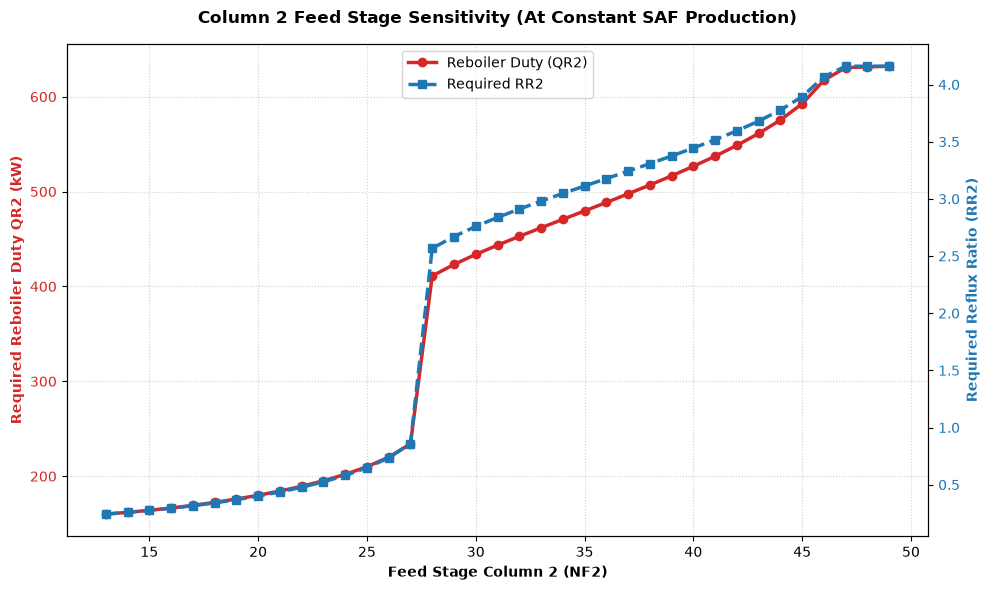

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from scipy.optimize import brentq  # For finding the RR2 that yields target SAF

# 1. LOAD SAVED MODEL AND SCALERS GLOBALLY
surrogate_net = load_model("mb_best_model_run_based.keras")
scaler_X = joblib.load("mb_best_X_scaler.joblib")
scaler_y = joblib.load("mb_best_y_scaler.joblib")

# Define a baseline constant configuration
baseline = {
    'INPUT FLOW': 2000,
    'N1': opt_list[1],
    'N2': opt_list[2],
    'NF1': opt_list[3],
    # 'NF2': opt_list[4],  # This will be varied now
    'RR1': opt_list[5],
    'RR2': opt_list[6],    # This will now serve as the initial guess / baseline
    'BF1': opt_list[7],
    'BF2': opt_list[8]
}

# --- define target SAF and search bounds ---
# We use the baseline setup to find our "constant product flow" target
Y_input = baseline['INPUT FLOW'] * baseline['BF1']
baseline_row = [
    baseline['INPUT FLOW'], baseline['N1'], baseline['N2'], baseline['NF1'],
    baseline['RR2'],  # using baseline RR2 as nominal
    baseline['RR1'], baseline['RR2'], baseline['BF1'], baseline['BF2'], Y_input
]
# Let's dynamically find your target SAF under optimal conditions:
baseline_scaled_in = scaler_X.transform([baseline_row])
baseline_unscaled_out = scaler_y.inverse_transform(surrogate_net.predict(baseline_scaled_in, verbose=0))[0]
target_SAF = baseline_unscaled_out[4] # Index 4 is SAF
print(f"Target SAF to maintain: {target_SAF:.4f} kg/h")

# Define range of Feed Stages for Column 2 to evaluate
# Note: Feed stage must be an integer between 2 and N2-1
N2_total = int(baseline['N2'])
NF2_range = np.arange(13, 50)

# --- Objective function to find RR2 ---
def evaluate_surrogate(rr2_candidate, nf2_current):
    """
    Runs the surrogate model for a candidate RR2 and current NF2,
    returning the predicted SAF.
    """
    row = [
        baseline['INPUT FLOW'],
        baseline['N1'],
        baseline['N2'],
        baseline['NF1'],
        nf2_current,          # Active feed stage
        baseline['RR1'],
        rr2_candidate,        # Target variable to solve for
        baseline['BF1'],
        baseline['BF2'],
        Y_input
    ]
    scaled_in = scaler_X.transform([row])
    scaled_out = surrogate_net.predict(scaled_in, verbose=0)
    unscaled_out = scaler_y.inverse_transform(scaled_out)[0]
    return unscaled_out  # returns all unscaled outputs

def objective_function(rr2_candidate, nf2_current, target):
    """
    Returns the difference between predicted SAF and target SAF.
    Objective is to find root where this difference is 0.
    """
    outputs = evaluate_surrogate(rr2_candidate, nf2_current)
    predicted_saf = outputs[4]
    return predicted_saf - target

# --- Loop over feed stage range ---
sensitivity_results = []
rr2_min_bound, rr2_max_bound = 0.16, 4.16 # Search range for RR2

for nf2 in NF2_range:
    try:
        # Check if a root exists in our RR2 boundaries (signs must be opposite)
        f_min = objective_function(rr2_min_bound, nf2, target_SAF)
        f_max = objective_function(rr2_max_bound, nf2, target_SAF)

        if f_min * f_max > 0:
            # If target SAF is outside the boundaries, find the closest possible value using minimization
            from scipy.optimize import minimize_scalar
            res = minimize_scalar(
                lambda r: abs(objective_function(r, nf2, target_SAF)),
                bounds=(rr2_min_bound, rr2_max_bound),
                method='bounded'
            )
            required_rr2 = res.x
        else:
            # Solve exactly for the RR2 that yields target SAF
            required_rr2 = brentq(
                objective_function,
                rr2_min_bound,
                rr2_max_bound,
                args=(nf2, target_SAF),
                xtol=1e-4
            )

        # Now run model one last time at the found RR2 to get corresponding Reboiler Duty (QR2)
        final_outputs = evaluate_surrogate(required_rr2, nf2)
        qr2 = final_outputs[1]  # Index 1 is QREB2
        saf_check = final_outputs[4]

        sensitivity_results.append({
            'NF2': nf2,
            'Required_RR2': required_rr2,
            'QR2': qr2,
            'SAF': saf_check
        })
        print(f"Feed Stage {nf2}: Found RR2 = {required_rr2:.3f} | QR2 = {qr2:.2f} kW | SAF = {saf_check:.2f} kg/h")

    except Exception as e:
        print(f"Could not solve for Feed Stage {nf2}: {e}")

# Convert to DataFrame
sens_results_df = pd.DataFrame(sensitivity_results)

# --- PLOT SENSITIVITY VISUALIZATION ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Feed Stage Column 2 (NF2)', fontweight='bold')
ax1.set_ylabel('Required Reboiler Duty QR2 (kW)', color=color, fontweight='bold')
line1 = ax1.plot(sens_results_df['NF2'], sens_results_df['QR2'], color=color, marker='o', linewidth=2.5, label='Reboiler Duty (QR2)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Instantiate a second axes that shares the same x-axis for required reflux ratio
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Required Reflux Ratio (RR2)', color=color, fontweight='bold')
line2 = ax2.plot(sens_results_df['NF2'], sens_results_df['Required_RR2'], color=color, marker='s', linewidth=2.5, linestyle='--', label='Required RR2')
ax2.tick_params(axis='y', labelcolor=color)

# Added unified legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title('Column 2 Feed Stage Sensitivity (At Constant SAF Production)', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()